Opens data set

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#read data and convert to CSV
data_file = pd.read_excel("Real estate valuation data set.xlsx")
data_file.to_csv("data.csv", index=False)

#opens data folder, now a CSV
with open('data.csv', encoding="utf-8") as f:
   i = 0
   X1 = []
   X2 = []
   X3 = []
   X4 = []
   X5 = []
   X6 = []
   Y = []
   for line in f:
      '''
      if i < 3:
         print(line)
      '''
      if i == 0:
          i = 1
          continue
      words = line.split(",")
      X1.append(float(words[1]))
      X2.append(float(words[2]))
      X3.append(float(words[3]))
      X4.append(float(words[4]))
      X5.append(float(words[5]))
      X6.append(float(words[6]))
      Y.append(float(words[7]))
      i = i + 1

Question 1

There are 414 data points in the data set
X1 lies in between 2012.6666667 and 2013.5833333
X2 lies in between 0.0 and 43.8
X3 lies in between 23.38284 and 6488.021
X4 lies in between 0.0 and 10.0
X5 lies in between 24.93207 and 25.01459
X6 lies in between 121.47353 and 121.56627
Y lies in between 7.6 and 117.5
24.9746,121.53046
252.5822


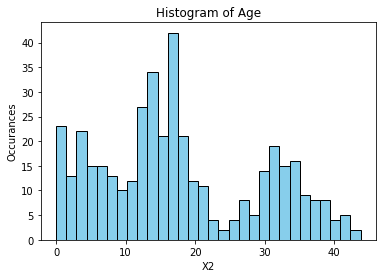

In [24]:

print(f"There are {len(X1)} data points in the data set")
print(f"X1 lies in between {min(X1)} and {max(X1)}")
print(f"X2 lies in between {min(X2)} and {max(X2)}")
print(f"X3 lies in between {min(X3)} and {max(X3)}")
print(f"X4 lies in between {min(X4)} and {max(X4)}")
print(f"X5 lies in between {min(X5)} and {max(X5)}")
print(f"X6 lies in between {min(X6)} and {max(X6)}")
print(f"Y lies in between {min(Y)} and {max(Y)}")

outlier_index = Y.index(max(Y))
print(f"{X5[outlier_index]},{X6[outlier_index]}")
print(f"{X3[outlier_index]}")

# compares X_i to Y graphically 

plt.hist(X2, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("X2")
plt.ylabel("Occurances")
plt.title("Histogram of Age")
plt.show()


Question 1 part b

w0: 42.43469704625073, w1: -0.25148841908485936, final_loss: 36535.598124481985


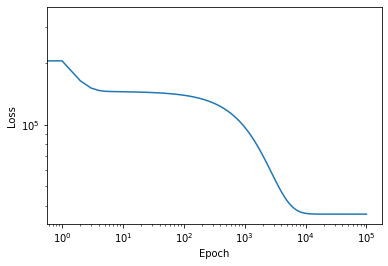

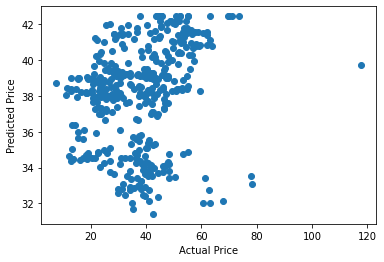

In [25]:

def hat_y(x,w0,w1):
    # hat y for part b
    return w0 + w1 * x

def get_L(X, w0,w1):
    # computes the loss function for part b
        return .5 * np.sum((Y - hat_y(X,w0,w1))**2)
        
w0 = 0
w1 = 0
N = len(Y)
epochs = 10**(5)
X2 = np.array(X2)
Y = np.array(Y)
xbar = np.sum(X2)/N
ybar = np.sum(Y)/N
A = np.dot(X2,Y)/N
B = np.dot(X2,X2)/N
alpha = 1/1000
Losses = []
Epoch = []
W1s = []
for j in range(epochs):
    Epoch.append(j)
    Losses.append(get_L(X2, w0,w1))
    w0 = w0 + alpha* (ybar - w0 - w1 * xbar)
    w1 = w1 + alpha * (A - w0 * xbar - B*w1)

plt.loglog(Epoch, Losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
print(f"w0: {w0}, w1: {w1}, final_loss: {Losses[-1]}")
plt.show()

plt.scatter(Y, hat_y(X2,w0, w1), label = 'one-feature')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

Part c

Mean_2: 17.71256038647343
Mean_3: 1083.8856889130436
Standard_2: 11.378717175302857
Standard_3: 1260.5843868803893


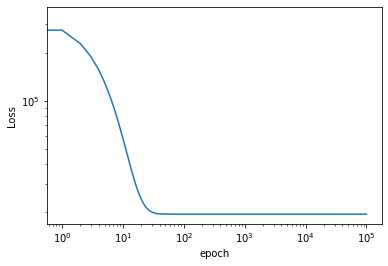

The final loss is 19453.81231535184
W0 is 49.8855857569066
W1 is -0.23102658345724797
W2 is -0.007208620143015232


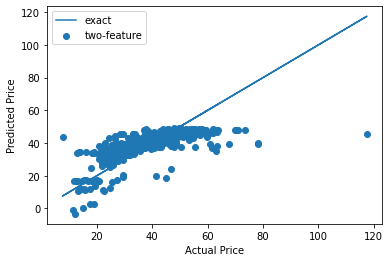

In [26]:

X2 = np.array(X2)
X3 = np.array(X3)
y1 = np.ones(len(X2))
N = len(X2)

#conditioning the data
mean_2 = np.sum(X2)/N
mean_3 = np.sum(X3)/N
std2 = np.sqrt(np.sum((X2-mean_2)**2)/N)
std3 = np.sqrt(np.sum((X3-mean_3)**2)/N)
print(f"Mean_2: {mean_2}")
print(f"Mean_3: {mean_3}")
print(f"Standard_2: {std2}")
print(f"Standard_3: {std3}")

#normalized_data 
y2 = (X2 - mean_2)/std2
y3 = (X3 - mean_3)/std3



feature_matrix = np.zeros([len(X1), 3])
feature_matrix[:, 0]  = y1
feature_matrix[:,1] = y2
feature_matrix[:,2] = y3

def get_L(W):
    return np.sum(((Y - W[1] * y2 - W[2]*y3 - W[0] * y1)**2)*.5)

X = feature_matrix.T@feature_matrix/N
S = feature_matrix.T @ Y / N
W = np.array([0,0,0])

epochs = 1*10**(5)
alpha = 10**(-1)
Losses = [get_L(W)]
iterate = [0]
for i in range(epochs):
    W = W - alpha * X @ W + alpha*S
    Losses.append(get_L(W))
    iterate.append(i+1)

plt.loglog(iterate,Losses)
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.show()
print(f"The final loss is {Losses[-1]}")
print(f"W0 is {W[0] - mean_2/std2*W[1] - mean_3/std3*W[2]}")
print(f"W1 is {W[1]/std2}")
print(f"W2 is {W[2]/std3}")


#scatter of predicted vs actual price
plt.scatter(Y, W[1] * y2 + W[2]*y3 +W[0] * y1, label = 'two-feature')
plt.plot(Y,Y, label = "exact")
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()


Part d

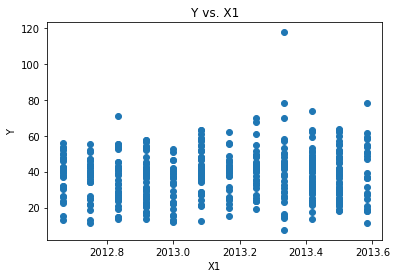

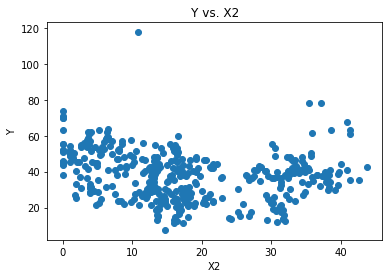

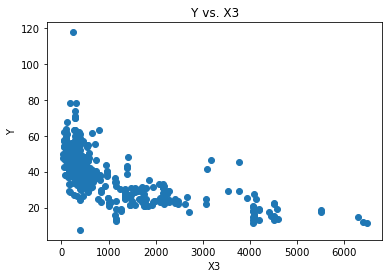

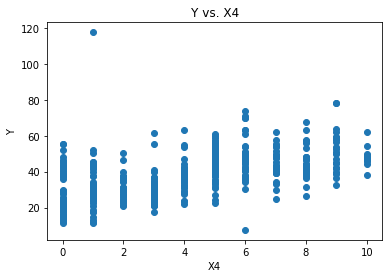

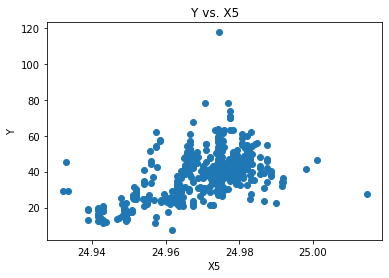

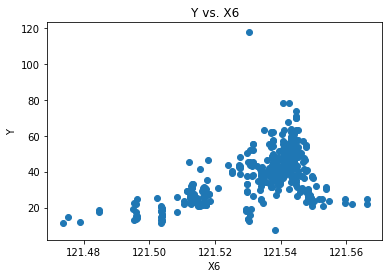

In [27]:
plt.scatter(X1, Y)
plt.title("Y vs. X1")
plt.xlabel("X1")
plt.ylabel("Y")
plt.show()

plt.scatter(X2, Y)
plt.title("Y vs. X2")
plt.xlabel("X2")
plt.ylabel("Y")
plt.show()

plt.scatter(X3, Y)
plt.title("Y vs. X3")
plt.xlabel("X3")
plt.ylabel("Y")
plt.show()

plt.scatter(X4, Y)
plt.title("Y vs. X4")
plt.xlabel("X4")
plt.ylabel("Y")
plt.show()

plt.scatter(X5, Y)
plt.title("Y vs. X5")
plt.xlabel("X5")
plt.ylabel("Y")
plt.show()

plt.scatter(X6, Y)
plt.title("Y vs. X6")
plt.xlabel("X6")
plt.ylabel("Y")
plt.show()

Code for part e

[ 4.98855858e+01 -2.31026583e-01 -7.20862014e-03]
The exact weights (w0,w1,w2) = [ 4.98855858e+01 -2.31026583e-01 -7.20862014e-03]


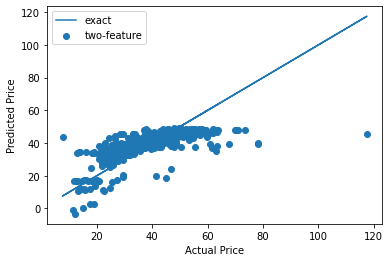

final loss: 19453.812315351843


In [28]:

fet_matrix = np.zeros((len(Y),3))
X1 = np.ones(len(Y))

fet_matrix[:,0] = X1
fet_matrix[:,1] = X2
fet_matrix[:,2] = X3

S = fet_matrix.T @ Y
A = fet_matrix.T @ fet_matrix
W = np.linalg.solve(A,S)

print(W)
print(f"The exact weights (w0,w1,w2) = {W}")

plt.scatter(Y, W[1] * np.array(X2) + W[2]*np.array(X3) +W[0] * X1, label = 'two-feature')
plt.plot(Y,Y, label = "exact")
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

print(f"final loss: {np.sum(((Y - W[1] * np.array(X2) - W[2]*np.array(X3) - W[0] * X1)**2)*.5 )}")
